# **Média de Tempo de Tela para Crianças**

* O dataset utilizado neste projeto pode ser encontrado [aqui](https://www.kaggle.com/datasets/ak0212/average-daily-screen-time-for-children).

## **1\. Motivação**

Este é um trabalho desenvolvido para estudo de Machine Learning e tem a motivação de encontrar um conjunto de perfis médios e alocar as crianças ao perfil mais próximo

> Qual a quantidade de grupos?

> Quais são as características de cada grupo?

> O tipo de tempo de tela influencia na média de uso?

# **2\. Análise Exploratória de Dados (EDA)**

## **2.1. Importação das Bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
model = KMeans()

## **2.2. Leitura do Dataset**

In [ ]:
screen_time = pd.read_csv('screen_time.csv')

## **2.3. Visão Geral**

In [ ]:
screen_time.head()

,Age,Gender,Screen Time Type,Day Type,Average Screen Time (hours),Sample Size
0,5,Male,Educational,Weekday,0.44,500
1,5,Male,Recreational,Weekday,1.11,500
2,5,Male,Total,Weekday,1.55,500
3,5,Male,Educational,Weekend,0.50,500
4,5,Male,Recreational,Weekend,1.44,500


In [ ]:
screen_time.tail()

,Age,Gender,Screen Time Type,Day Type,Average Screen Time (hours),Sample Size
193,15,Other/Prefer not to say,Recreational,Weekday,5.16,300
194,15,Other/Prefer not to say,Total,Weekday,6.50,300
195,15,Other/Prefer not to say,Educational,Weekend,2.19,300
196,15,Other/Prefer not to say,Recreational,Weekend,5.77,300
197,15,Other/Prefer not to say,Total,Weekend,7.96,300


In [ ]:
screen_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          198 non-null    int64  
 1   Gender                       198 non-null    object 
 2   Screen Time Type             198 non-null    object 
 3   Day Type                     198 non-null    object 
 4   Average Screen Time (hours)  198 non-null    float64
 5   Sample Size                  198 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.4+ KB


In [ ]:
screen_time.describe()

,Age,Average Screen Time (hours),Sample Size
count,198.000000,198.000000,198.000000
mean,10.000000,2.993030,400.000000
std,3.170294,1.922822,63.405872
min,5.000000,0.440000,300.000000
25%,7.000000,1.402500,340.000000
50%,10.000000,2.490000,400.000000
75%,13.000000,4.397500,460.000000
max,15.000000,8.190000,500.000000


In [ ]:
screen_time["Screen Time Type"].value_counts()

,count
Screen Time Type,
Educational,66
Recreational,66
Total,66


In [ ]:
screen_time["Day Type"].value_counts()

,count
Day Type,
Weekday,99
Weekend,99


In [ ]:
screen_time["Gender"].value_counts()

,count
Gender,
Male,66
Female,66
Other/Prefer not to say,66


In [ ]:
screen_time.columns

Index(['Age', 'Gender', 'Screen Time Type', 'Day Type',
       'Average Screen Time (hours)', 'Sample Size'],
      dtype='object')

In [ ]:
screen_time.nunique()

,0
Age,11
Gender,3
Screen Time Type,3
Day Type,2
Average Screen Time (hours),172
Sample Size,11


## **2.3. Análise Visual**

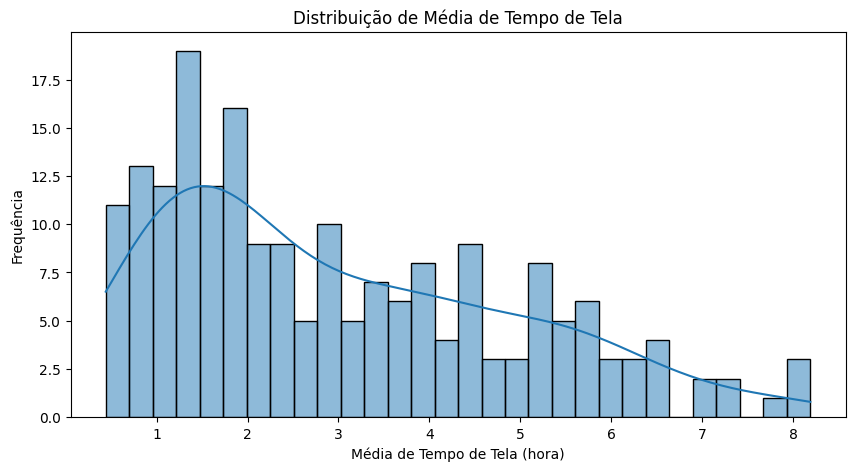

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(screen_time["Average Screen Time (hours)"], bins=30, kde=True)
plt.title("Distribuição de Média de Tempo de Tela")
plt.xlabel("Média de Tempo de Tela (hora)")
plt.ylabel("Frequência")
plt.show()

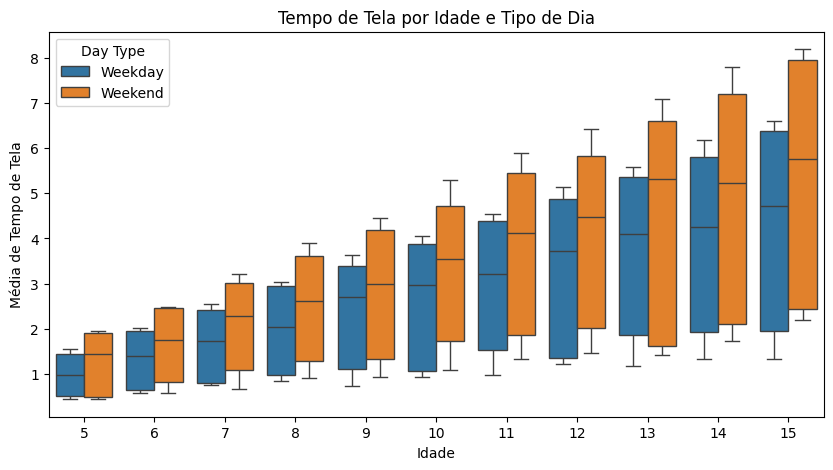

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=screen_time, x="Age", y="Average Screen Time (hours)", hue="Day Type")
plt.title("Tempo de Tela por Idade e Tipo de Dia")
plt.xlabel("Idade")
plt.ylabel("Média de Tempo de Tela")
plt.show()

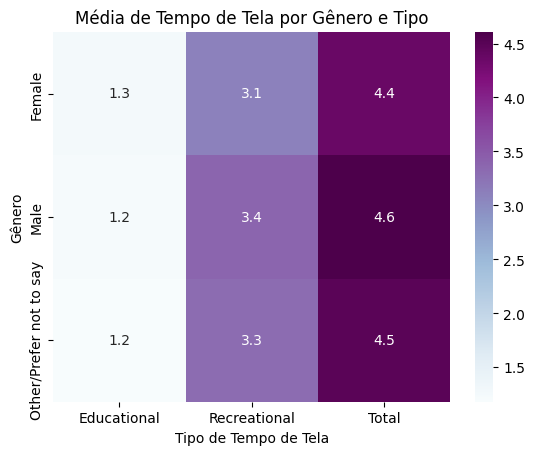

In [ ]:
pivot = screen_time.pivot_table(index="Gender", columns="Screen Time Type", values="Average Screen Time (hours)")
sns.heatmap(pivot, annot=True, cmap="BuPu")
plt.title("Média de Tempo de Tela por Gênero e Tipo")
plt.xlabel("Tipo de Tempo de Tela")
plt.ylabel("Gênero")
plt.show()

# 3\. **Data Wrangling**

## **3.1. Codficando atributos tipo string**

In [ ]:
le = LabelEncoder()
screen_time["Gender"] = le.fit_transform(screen_time["Gender"])  # Male: 1, Female: 0
screen_time["Day Type"] = le.fit_transform(screen_time["Day Type"])  # Weekday: 1, Weekend: 0
screen_time["Screen Time Type"] = le.fit_transform(screen_time["Screen Time Type"])  # Educational: 0, Recreational: 1, Total: 2

In [ ]:
screen_time.drop('Sample Size', axis=1, inplace=True)

In [ ]:
screen_time.head()

,Age,Gender,Screen Time Type,Day Type,Average Screen Time (hours)
0,5,1,0,0,0.44
1,5,1,1,0,1.11
2,5,1,2,0,1.55
3,5,1,0,1,0.50
4,5,1,1,1,1.44


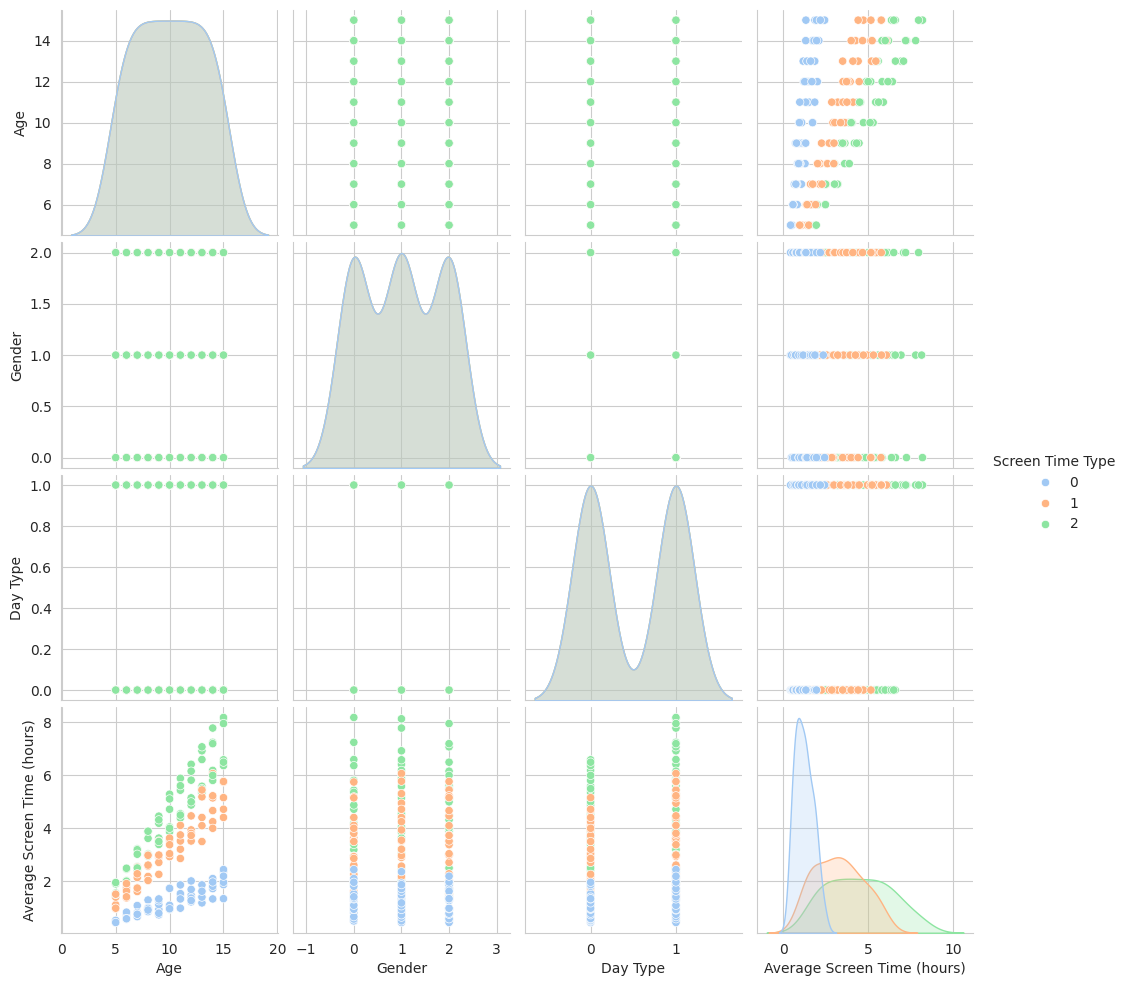

In [ ]:
with sns.axes_style('whitegrid'):

  grafico = sns.pairplot(data=screen_time, hue = 'Screen Time Type', palette = 'pastel')

# **4\. Treino**

> Como o nosso objetivo é identificar padrões, iremos utilizar o treino de modelo de k-means.

Para identificar a quantidade ideal de Clusters para a nossa análise, iremos utilizar o WCSS - Método do Cotovelo.

## **4.1. WCSS**

In [ ]:
wcss = []

for k in range(1, 11):

  model = KMeans(n_clusters=k)
  model = model.fit(screen_time)
  wcss.append(model.inertia_)

<ipython-input-101-2ab4f683a5c6>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  grafico = sns.lineplot(x=range(1, 11), y=wcss, marker="8", palette="pastel")


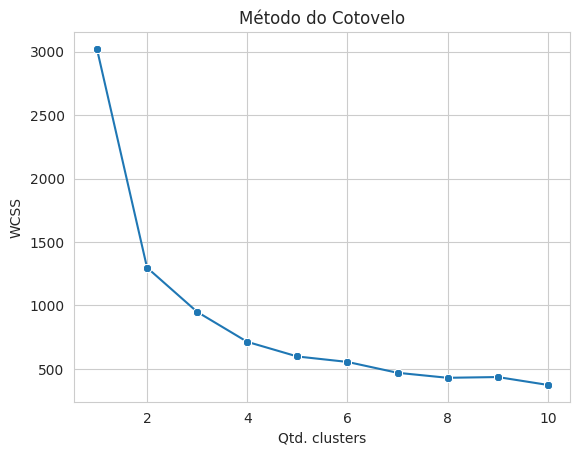

In [ ]:
with sns.axes_style('whitegrid'):

  grafico = sns.lineplot(x=range(1, 11), y=wcss, marker="8", palette="pastel")
  grafico.set(title='Método do Cotovelo', ylabel='WCSS', xlabel='Qtd. clusters');

> A partir do gráfico acima, podemos identificar que o número ideal de Clusters pode ser entre 3 e 5. Neste caso escolheremos trabalhar com 4 Clusters.

## **4.2. Clustering (K-Means)**

In [ ]:
model = KMeans(n_clusters=4)
model = model.fit(screen_time)

In [ ]:
clusters = model.labels_
clusters = pd.DataFrame(clusters, columns=['cluster'])
clusters.head()

,cluster
0,1
1,1
2,1
3,1
4,1


In [ ]:
clustered_data = pd.concat([screen_time, clusters], axis=1)
clustered_data.head()

,Age,Gender,Screen Time Type,Day Type,Average Screen Time (hours),cluster
0,5,1,0,0,0.44,1
1,5,1,1,0,1.11,1
2,5,1,2,0,1.55,1
3,5,1,0,1,0.50,1
4,5,1,1,1,1.44,1


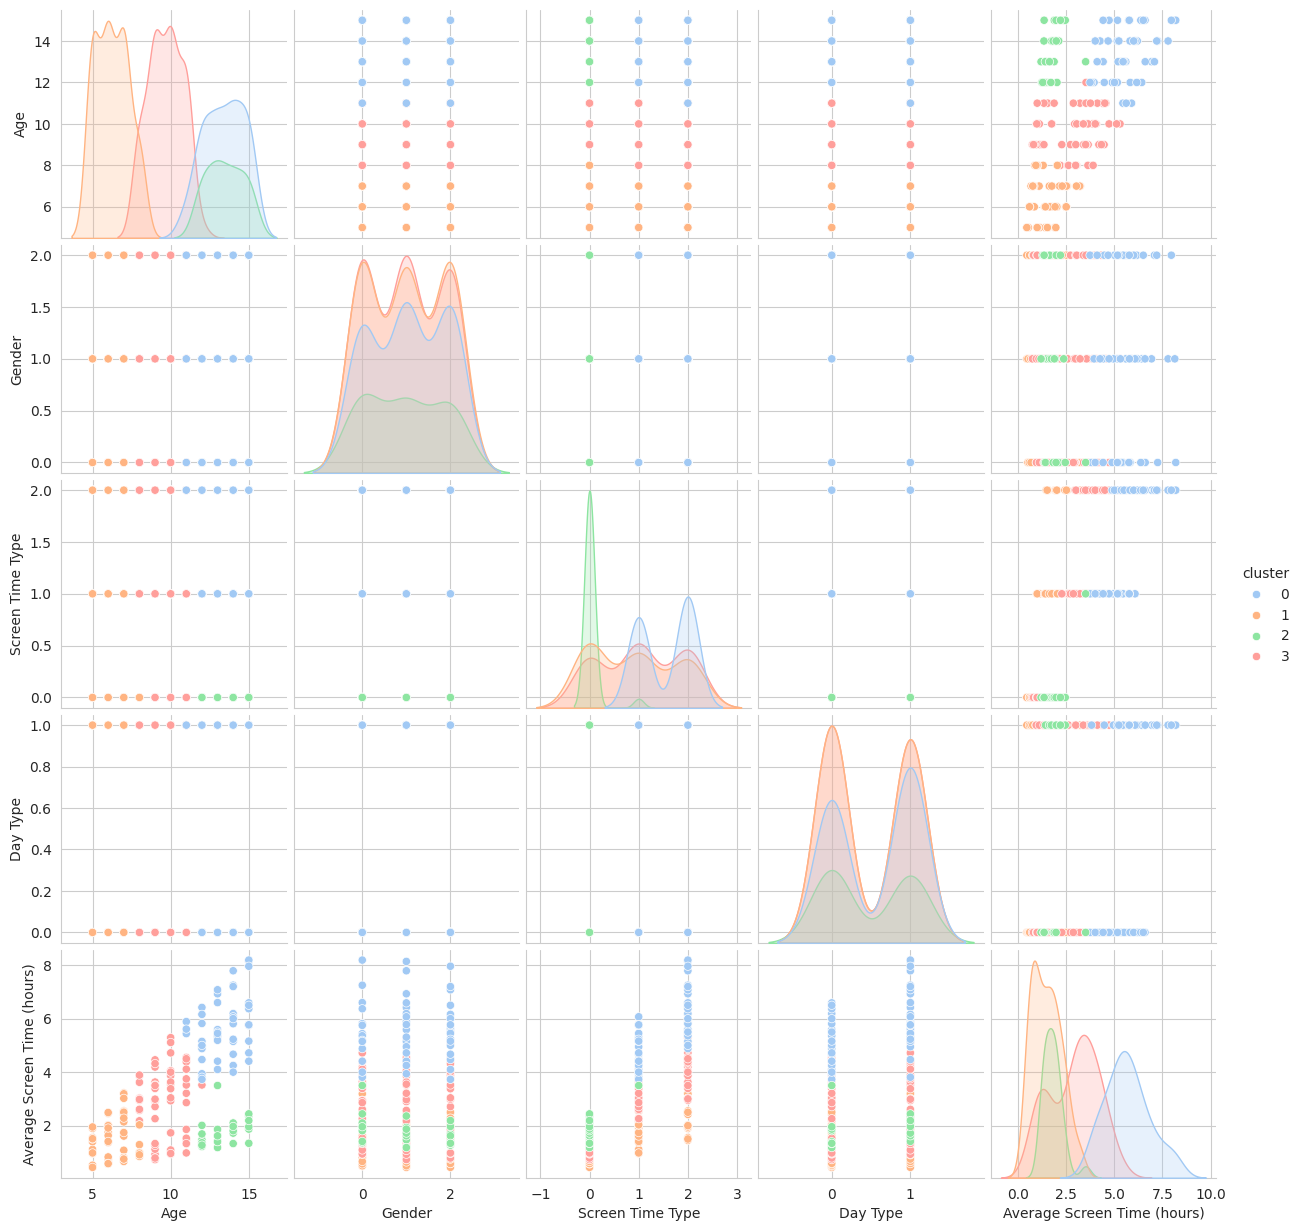

In [ ]:
with sns.axes_style('whitegrid'):

  grafico = sns.pairplot(data=clustered_data, hue = 'cluster', palette = 'pastel')

In [ ]:
clusters_centers = model.cluster_centers_
clusters_centers = pd.DataFrame(clusters_centers, columns=screen_time.columns)
clusters_centers

,Age,Gender,Screen Time Type,Day Type,Average Screen Time (hours)
0,13.387755,1.040816,1.551020,0.551020,5.668163
1,6.258065,1.000000,0.903226,0.483871,1.470968
2,13.480000,0.960000,0.040000,0.480000,1.785200
3,9.661290,0.983871,1.048387,0.483871,2.887903


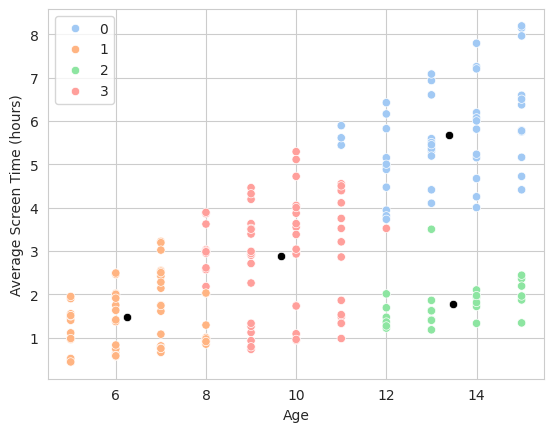

In [ ]:
with sns.axes_style('whitegrid'):

  fig, ax = plt.subplots()
  sns.scatterplot(data=clustered_data,   x='Age', y='Average Screen Time (hours)', hue='cluster', palette="pastel", ax=ax)
  sns.scatterplot(data=clusters_centers, x='Age', y='Average Screen Time (hours)', color='black', ax=ax)

# **5\. Predição**

In [ ]:
screen_time.head()

,Age,Gender,Screen Time Type,Day Type,Average Screen Time (hours)
0,5,1,0,0,0.44
1,5,1,1,0,1.11
2,5,1,2,0,1.55
3,5,1,0,1,0.50
4,5,1,1,1,1.44


> **Exemplo:**

* Age: 9
* Gender: 1
* Screen Time Type: 0
* Day Type: 1
* Avarage Screen Time (hours): 2.00

In [ ]:
criança = np.array([9, 1, 0, 1, 2.00])

In [ ]:
cluster = model.predict(criança.reshape(1, -1))
print(cluster)

[3]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


> Conclui-se então que o cliente pertence ao cluster 3.

# **6\. Conclusão**

A partir desta base de dados podemos identificar uma correlação geral entre a idade e a média do tempo de tela: quanto mais velha a criança, mais tempo de tela ela tem.

Também podemos observar que um dos Clusters (2) mostra crianças que fogem dessa regra: apesar de serem mais velhas, mantiveram o tempo de tela bais baixo.

Com uma análise mais detalhada vemos que a maioria das crianças deste Cluster (2) não utiliza telas de forma recreativa, apenas para fins educacionais.

* **Utilizando o K-Means podemos responder os nossos questionamentos iniciais:**

> **Qual a quantidade de grupos?**

Identificamos 4 grupos diferentes

> **Quais são as características de cada grupo?**

Cluster 0: Crianças entre 11 e 15 anos com alta média de tempo de tela

Cluster 1: Crianças entre 5 e 8 anos com média de tempo de tela de até 3,5 horas

Cluster 2: Crianças entre 12 e 15 anos com baixa média de tempo de tela

Cluster 3: Crianças entre 8 e 12 anos com média de tempo de tela de até 5,5 horas

> **O tipo de tempo de tela influencia na média de uso?**

Sim, as crianças que utilizam pouco ou nada do tempo de tela para fins recreativos tendem a ter uma menor média de tempo de tela total.